In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 2157 binary executable samples comprising 1134 legitimate software (goodware) and 1023 ransomware, grouped into 25 ransomware families. The dataset was retrieved by extracting raw information of the PE header (first 1024 bytes).

The CSV file columns are sample ID, filename, target class (GR), family ID, and numerical columns from 0 to 1023, as
follows:


	|   GR      | 	ID	     | 	filename   	| GR |  family	| 	0 - 1023
    |  Goodware | 10000 to 11133 | Their name.exe	 | 0  |  0		 | Numerical features ranging from 0 to 255
    | Ransomware| 20000 to 21022 | Their SHA-256 hash | 1  | 25 family IDs	| Numerical features ranging from 0 to 255	|

Family IDs:
- Avaddon			1
- Babuk			2
- Blackmatter		3
- Conti			4
- Darkside			5
- Dharma			6
- Doppelpaymer	7
- Exorcist			8
- Gandcrab		9
- Lockbit			10
- Makop			11
- Maze			12
- Mountlocker		13
- Nefilim			14
- Netwalker		15
- Phobos			16
- Pysa				17
- Ragnarok		18
- RansomeXX		19
- Revil			20
- Ryuk			21
- Stop				22
- Thanos			23
- Wastedlocker		24
- Zeppelin			25

In [12]:
df = pd.read_csv('Ransomware_headers.csv')

In [13]:
# preview data
df.head()

,ID,filename,GR,family,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,10000,2XClient_12.0_build_2193.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1,10001,7-ZipPortable_21.07.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
2,10002,ARP.EXE,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
3,10003,AccountsControlHost.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
4,10004,ActionUriServer.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# PE Header 1024
df.iloc[:, 4:]

,filename,GR,family,0,1,2,3,4,5,6,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,2XClient_12.0_build_2193.paf.exe,0,0,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7-ZipPortable_21.07.paf.exe,0,0,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ARP.EXE,0,0,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AccountsControlHost.exe,0,0,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ActionUriServer.exe,0,0,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2152,ece7ddff2ff9fdb8e7f55b674baa9c975ce86ff79e02db...,1,25,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
2153,f247ae6db52989c9a598c3c7fbc1ae2db54f5c65be8628...,1,25,77,90,80,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
2154,f38c40c74a0a9953697c63fbd375c064cb2d59ce478435...,1,25,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
2155,fa789f56ef3f5075fc02c53cd937fe1580ae46217cf0a8...,1,25,77,90,144,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df.sample(9,random_state=42)

,ID,filename,GR,family,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
746,10746,curl.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1677,20543,b227fa0485e34511627a8a4a7d3f1abb6231517be62d02...,1,14,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1858,20724,9706a97ffa43a0258571def8912dc2b8bf1ee207676052...,1,18,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1657,20523,0bafde9b22d7147de8fdb852bcd529b1730acddc9eb713...,1,14,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
479,10479,SensorDataService.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1730,20596,b96ee4a55d59836de7851f99a18324c6aa8bc223fb581f...,1,15,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1452,20318,bf6e5f9d060ebc5bb70144ca6e795bfc249c6590ab9f45...,1,8,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
905,10905,net1.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
605,10605,WallpaperHost.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

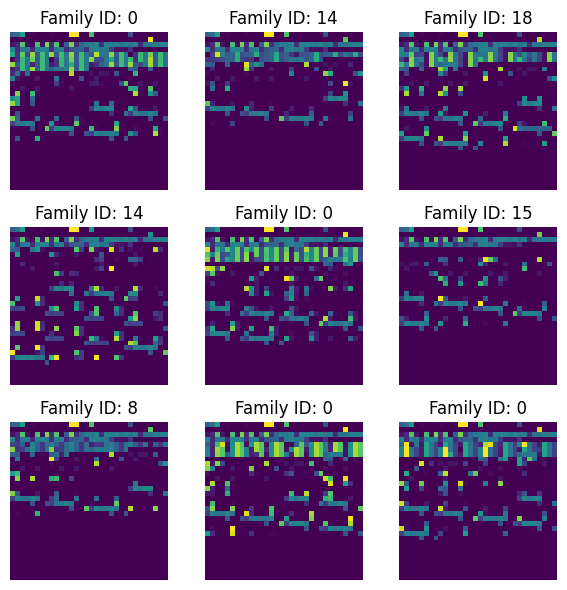

In [4]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 4:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family ID: {samp.iloc[i, 3]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [16]:
# Split the data into training and validation sets (70% for training, 15% for validation, 15% for test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [17]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [18]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [19]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
model.fit(train_images, train_labels, epochs=25, validation_data=(val_images, val_labels))

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - accuracy: 0.5435 - loss: 3.8285 - val_accuracy: 0.6159 - val_loss: 0.8032
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 233s 4s/step - accuracy: 0.6115 - loss: 0.7296 - val_accuracy: 0.7474 - val_loss: 0.5025
Epoch 3/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.6729 - loss: 0.6091 - val_accuracy: 0.7578 - val_loss: 0.5007
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - accuracy: 0.7639 - loss: 0.4736 - val_accuracy: 0.7266 - val_loss: 0.5748
Epoch 5/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.8082 - loss: 0.4515 - val_accuracy: 0.8339 - val_loss: 0.4144
Epoch 6/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - accuracy: 0.7366 - loss: 0.5389 - val_accuracy: 0.7059 - val_loss: 0.5809
Epoch 7/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.8084 - loss: 0.4310 - val_accuracy: 0.7612 - val_loss: 0.5081
Epoch 8/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.7173 - loss: 0.5596 - val_accuracy: 0.7266 - v

In [22]:
y_pred = model.predict(test_images)

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step


In [23]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.89      0.89      0.89        79
 Ransomeware       0.86      0.86      0.86        64

    accuracy                           0.87       143
   macro avg       0.87      0.87      0.87       143
weighted avg       0.87      0.87      0.87       143



In [24]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.89      0.89      0.89        79
 Ransomeware       0.86      0.86      0.86        64

    accuracy                           0.87       143
   macro avg       0.87      0.87      0.87       143
weighted avg       0.87      0.87      0.87       143

Confusion Matrix: 
[[70  9]
 [ 9 55]]
Precision: 0.8594
Recall: 0.8594
Accuracy: 0.8741
FN Rate: 0.1406
FP Rate: 0.1139
F-measure: 0.8594
Error Rate: 0.1259
MCC: 0.7455
Kappa: 0.7455
AUC-ROC: 0.9312


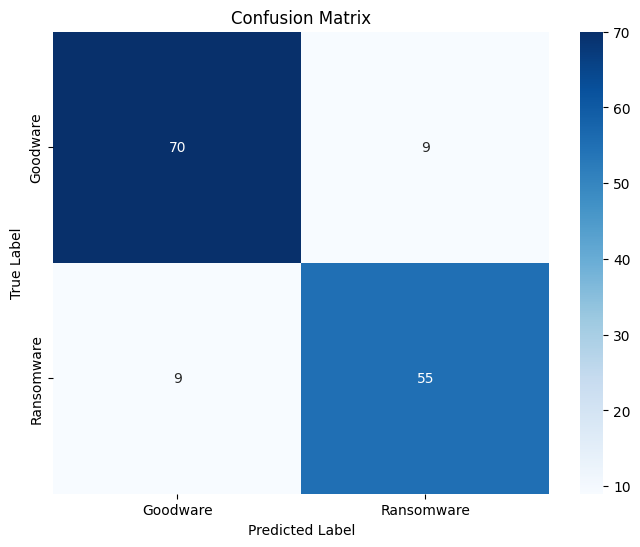

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [26]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

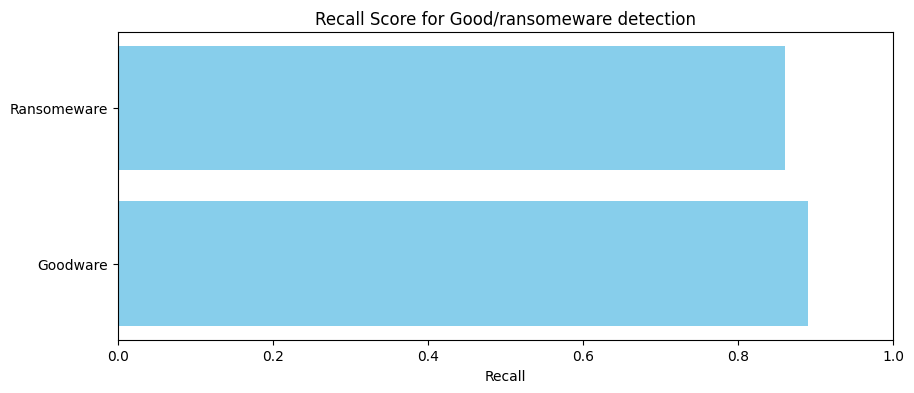

In [27]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [28]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [29]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [30]:
# Compile the model
model_xception.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [31]:
# train model
model_xception.fit(train_images, train_labels, epochs=25, validation_data=(val_images, val_labels))

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.6240 - loss: 3.2399 - val_accuracy: 0.8616 - val_loss: 0.4746
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.8850 - loss: 0.3316 - val_accuracy: 0.9066 - val_loss: 0.2587
Epoch 3/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.9395 - loss: 0.1370 - val_accuracy: 0.9239 - val_loss: 0.1737
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.9132 - loss: 0.2235 - val_accuracy: 0.9204 - val_loss: 0.2288
Epoch 5/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.9600 - loss: 0.1208 - val_accuracy: 0.9516 - val_loss: 0.1455
Epoch 6/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9816 - loss: 0.0523 - val_accuracy: 0.9412 - val_loss: 0.1610
Epoch 7/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9930 - loss: 0.0334 - val_accuracy: 0.8858 - val_loss: 0.3471
Epoch 8/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9509 - loss: 0.1160 - val_accuracy: 0.9308 - v

In [34]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(test_images)

5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step


In [35]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.94      0.92      0.93        79
 Ransomeware       0.91      0.92      0.91        64

    accuracy                           0.92       143
   macro avg       0.92      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



In [36]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.94      0.92      0.93        79
 Ransomeware       0.91      0.92      0.91        64

    accuracy                           0.92       143
   macro avg       0.92      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143

Confusion Matrix: 
[[73  6]
 [ 5 59]]
Precision: 0.9077
Recall: 0.9219
Accuracy: 0.9231
FN Rate: 0.0781
FP Rate: 0.0759
F-measure: 0.9147
Error Rate: 0.0769
MCC: 0.8448
Kappa: 0.8447
AUC-ROC: 0.9790


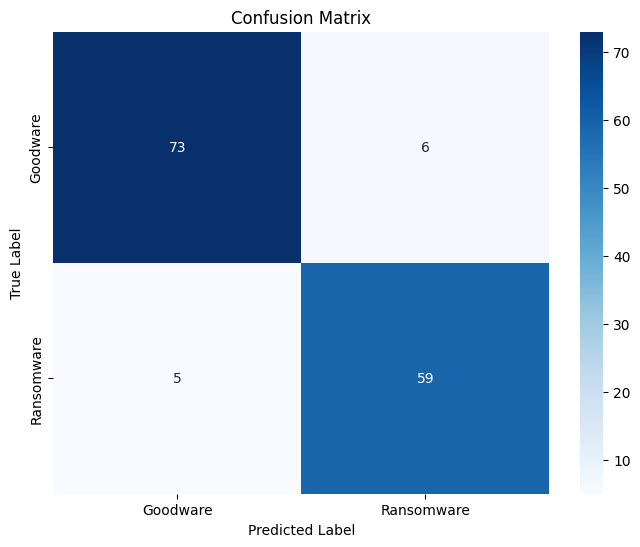

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

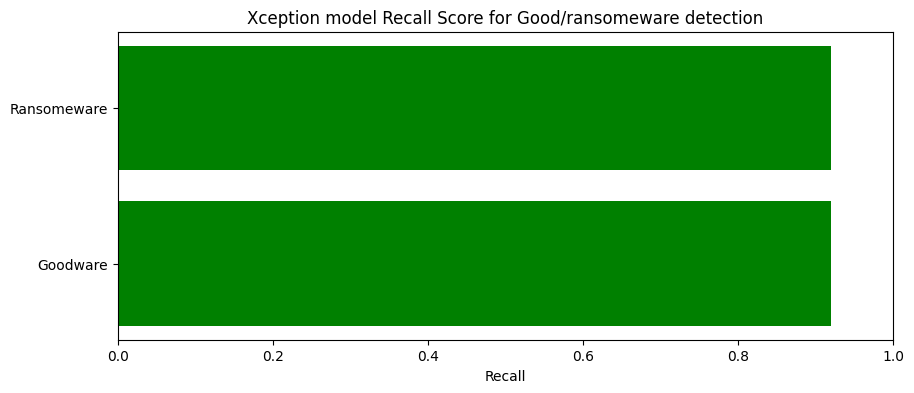

In [38]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [39]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [40]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [41]:
# Compile the model
model_VGG.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [42]:
# train model
model_VGG.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 587s 10s/step - accuracy: 0.7123 - loss: 0.6516 - val_accuracy: 0.8997 - val_loss: 0.2369
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 483s 9s/step - accuracy: 0.9026 - loss: 0.2399 - val_accuracy: 0.9239 - val_loss: 0.2022
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 489s 9s/step - accuracy: 0.9503 - loss: 0.1514 - val_accuracy: 0.9204 - val_loss: 0.1796
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 484s 9s/step - accuracy: 0.9622 - loss: 0.1058 - val_accuracy: 0.9100 - val_loss: 0.2087
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 493s 9s/step - accuracy: 0.9559 - loss: 0.1142 - val_accuracy: 0.9239 - val_loss: 0.1688
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 494s 9s/step - accuracy: 0.9822 - loss: 0.0745 - val_accuracy: 0.9308 - val_loss: 0.1811
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 495s 9s/step - accuracy: 0.9796 - loss: 0.0635 - val_accuracy: 0.9412 - val_loss: 0.1420
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 493s 9s/step - accuracy: 0.9879 - loss: 0.0467 - val_accuracy: 0.9516 - 

In [44]:
# Evaluate the model on the validation set
y_pred = model_VGG.predict(test_images)

5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step


In [45]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.97      0.91      0.94        79
 Ransomeware       0.90      0.97      0.93        64

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [46]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.97      0.91      0.94        79
 Ransomeware       0.90      0.97      0.93        64

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143

Confusion Matrix: 
[[72  7]
 [ 2 62]]
Precision: 0.8986
Recall: 0.9688
Accuracy: 0.9371
FN Rate: 0.0312
FP Rate: 0.0886
F-measure: 0.9323
Error Rate: 0.0629
MCC: 0.8758
Kappa: 0.8737
AUC-ROC: 0.9852


In [1]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'plt' is not defined

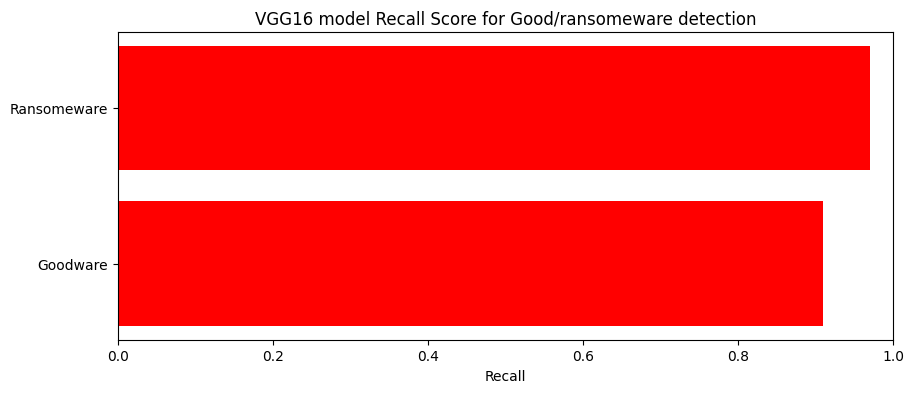

In [48]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()